### Spatial joining of Mission antyodaya data and Indian village shapefiles

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np

* All (most) the files are stored in parquet and Geoparquet format for quick analysis

In [ ]:
# Reading annual mean ndvi values for all villages extracted from google earth engine

villages_ndvi = pd.read_parquet(r'Indian_villages_NDVI.parquet')
villages_ndvi.head()

,state_name,district,village,NDVI_2021,NDVI_2022,NDVI_2023,NDVI_2024,NDVI_2025
0,Arunanchal Pradesh,West Kameng,Saljipam,0.756313,0.841046,0.816527,0.754949,0.820625
1,Arunanchal Pradesh,Pakke Kessang,Dibru,0.605078,0.706470,0.657217,0.681157,0.714061
2,Arunanchal Pradesh,Pakke Kessang,Giladhari,0.685343,0.742475,0.740275,0.739032,0.776911
3,Arunanchal Pradesh,Pakke Kessang,Rodoso,0.705609,0.726913,0.748370,0.773271,0.780828
4,Arunanchal Pradesh,Pakke Kessang,Chumgong,0.653542,0.678001,0.683652,0.733423,0.769311


In [ ]:
# Computing OLS slope to capture the trend of NDVI for each village

years  = villages_ndvi.columns[3:]

villages_ndvi[years] = villages_ndvi[years].apply(
    pd.to_numeric, errors="coerce"
)

x = np.arange(len(years))

X = x - x.mean()
denom = np.sum(X**2)

Y = villages_ndvi[years].values.astype(float)

Y_mean = Y.mean(axis=1, keepdims=True)

numerator = np.sum((Y - Y_mean) * X, axis=1)

villages_ndvi["ndvi_trend"] = numerator / denom

In [4]:
villages_ndvi.head()

,state_name,district,village,NDVI_2021,NDVI_2022,NDVI_2023,NDVI_2024,NDVI_2025,ndvi_trend
0,Arunanchal Pradesh,West Kameng,Saljipam,0.756313,0.841046,0.816527,0.754949,0.820625,0.004253
1,Arunanchal Pradesh,Pakke Kessang,Dibru,0.605078,0.706470,0.657217,0.681157,0.714061,0.019265
2,Arunanchal Pradesh,Pakke Kessang,Giladhari,0.685343,0.742475,0.740275,0.739032,0.776911,0.017969
3,Arunanchal Pradesh,Pakke Kessang,Rodoso,0.705609,0.726913,0.748370,0.773271,0.780828,0.019680
4,Arunanchal Pradesh,Pakke Kessang,Chumgong,0.653542,0.678001,0.683652,0.733423,0.769311,0.028696


In [5]:
villages_ndvi["ndvi_mean"] = villages_ndvi[years].mean(axis=1)
villages_ndvi["ndvi_std"] = villages_ndvi[years].std(axis=1)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# scale the data before developing index

villages_ndvi[["ndvi_mean_n","ndvi_trend_n", "ndvi_std_n"]] = scaler.fit_transform(
    villages_ndvi[["ndvi_mean","ndvi_trend", "ndvi_std"]]
)

In [ ]:
# giving arbitrary weight to each parameters

villages_ndvi["NDVI_index"] = (
    0.55 * villages_ndvi["ndvi_mean_n"] +
    0.35 * villages_ndvi["ndvi_trend_n"] +
    0.10 * (1 - villages_ndvi["ndvi_std_n"])
)

In [8]:
villages_ndvi.head()

,state_name,district,village,NDVI_2021,NDVI_2022,NDVI_2023,NDVI_2024,NDVI_2025,ndvi_trend,ndvi_mean,ndvi_std,ndvi_mean_n,ndvi_trend_n,ndvi_std_n,NDVI_index
0,Arunanchal Pradesh,West Kameng,Saljipam,0.756313,0.841046,0.816527,0.754949,0.820625,0.004253,0.797892,0.039684,0.946580,0.547744,0.106520,0.801677
1,Arunanchal Pradesh,Pakke Kessang,Dibru,0.605078,0.706470,0.657217,0.681157,0.714061,0.019265,0.672797,0.043974,0.818947,0.627911,0.118150,0.758375
2,Arunanchal Pradesh,Pakke Kessang,Giladhari,0.685343,0.742475,0.740275,0.739032,0.776911,0.017969,0.736807,0.032810,0.884256,0.620991,0.087890,0.794899
3,Arunanchal Pradesh,Pakke Kessang,Rodoso,0.705609,0.726913,0.748370,0.773271,0.780828,0.019680,0.746998,0.031437,0.894654,0.630124,0.084169,0.804186
4,Arunanchal Pradesh,Pakke Kessang,Chumgong,0.653542,0.678001,0.683652,0.733423,0.769311,0.028696,0.703586,0.046814,0.850361,0.678271,0.125848,0.792509


***

### Night light index

In [151]:
# The same analysis for Night lights

In [10]:
villages_nl = pd.read_parquet(r'Indian_villages_NightLights.parquet')
villages_nl.head()

,state_name,district,village,NL_2021,NL_2022,NL_2023,NL_2024,NL_2025
0,Arunanchal Pradesh,West Kameng,Saljipam,0.317500,0.352500,0.409167,0.386667,0.402500
1,Arunanchal Pradesh,Pakke Kessang,Dibru,0.361667,0.370000,0.492500,0.515000,0.358333
2,Arunanchal Pradesh,Pakke Kessang,Giladhari,0.372319,0.384529,0.382681,0.445399,0.338043
3,Arunanchal Pradesh,Pakke Kessang,Rodoso,0.307500,0.322500,0.421667,0.384167,0.321667
4,Arunanchal Pradesh,Pakke Kessang,Chumgong,0.260895,0.326543,0.346667,0.381975,0.310525


In [11]:
years  = villages_nl.columns[3:]

villages_nl[years] = villages_nl[years].apply(
    pd.to_numeric, errors="coerce"
)

x = np.arange(len(years))

X = x - x.mean()
denom = np.sum(X**2)

Y = villages_nl[years].values.astype(float)

Y_mean = Y.mean(axis=1, keepdims=True)

numerator = np.sum((Y - Y_mean) * X, axis=1)

villages_nl["nl_trend"] = numerator / denom

In [12]:
villages_nl.head()

,state_name,district,village,NL_2021,NL_2022,NL_2023,NL_2024,NL_2025,nl_trend
0,Arunanchal Pradesh,West Kameng,Saljipam,0.317500,0.352500,0.409167,0.386667,0.402500,0.020417
1,Arunanchal Pradesh,Pakke Kessang,Dibru,0.361667,0.370000,0.492500,0.515000,0.358333,0.013833
2,Arunanchal Pradesh,Pakke Kessang,Giladhari,0.372319,0.384529,0.382681,0.445399,0.338043,-0.000768
3,Arunanchal Pradesh,Pakke Kessang,Rodoso,0.307500,0.322500,0.421667,0.384167,0.321667,0.009000
4,Arunanchal Pradesh,Pakke Kessang,Chumgong,0.260895,0.326543,0.346667,0.381975,0.310525,0.015469


In [13]:
villages_nl["nl_mean"] = villages_nl[years].mean(axis=1)
villages_nl["nl_std"] = villages_nl[years].std(axis=1)

In [14]:
villages_nl.head()

,state_name,district,village,NL_2021,NL_2022,NL_2023,NL_2024,NL_2025,nl_trend,nl_mean,nl_std
0,Arunanchal Pradesh,West Kameng,Saljipam,0.317500,0.352500,0.409167,0.386667,0.402500,0.020417,0.373667,0.038286
1,Arunanchal Pradesh,Pakke Kessang,Dibru,0.361667,0.370000,0.492500,0.515000,0.358333,0.013833,0.419500,0.077436
2,Arunanchal Pradesh,Pakke Kessang,Giladhari,0.372319,0.384529,0.382681,0.445399,0.338043,-0.000768,0.384594,0.038789
3,Arunanchal Pradesh,Pakke Kessang,Rodoso,0.307500,0.322500,0.421667,0.384167,0.321667,0.009000,0.351500,0.049136
4,Arunanchal Pradesh,Pakke Kessang,Chumgong,0.260895,0.326543,0.346667,0.381975,0.310525,0.015469,0.325321,0.044823


In [ ]:
# Same weights given as NDVI Index

villages_nl[["nl_mean_n","nl_trend_n", "nl_std_n"]] = scaler.fit_transform(
    villages_nl[["nl_mean","nl_trend", "nl_std"]]
)

villages_nl["NL_index"] = (
    0.55 * villages_nl["nl_mean_n"] +
    0.35 * villages_nl["nl_trend_n"] +
    0.10 * (1 - villages_nl["nl_std_n"])
)



In [16]:
villages_nl.head()

,state_name,district,village,NL_2021,NL_2022,NL_2023,NL_2024,NL_2025,nl_trend,nl_mean,nl_std,nl_mean_n,nl_trend_n,nl_std_n,NL_index
0,Arunanchal Pradesh,West Kameng,Saljipam,0.317500,0.352500,0.409167,0.386667,0.402500,0.020417,0.373667,0.038286,0.000627,0.360036,0.000266,0.226331
1,Arunanchal Pradesh,Pakke Kessang,Dibru,0.361667,0.370000,0.492500,0.515000,0.358333,0.013833,0.419500,0.077436,0.000833,0.359980,0.000561,0.226395
2,Arunanchal Pradesh,Pakke Kessang,Giladhari,0.372319,0.384529,0.382681,0.445399,0.338043,-0.000768,0.384594,0.038789,0.000676,0.359857,0.000270,0.226295
3,Arunanchal Pradesh,Pakke Kessang,Rodoso,0.307500,0.322500,0.421667,0.384167,0.321667,0.009000,0.351500,0.049136,0.000528,0.359939,0.000348,0.226234
4,Arunanchal Pradesh,Pakke Kessang,Chumgong,0.260895,0.326543,0.346667,0.381975,0.310525,0.015469,0.325321,0.044823,0.000411,0.359994,0.000316,0.226192


In [17]:
villages_nl = villages_nl.drop_duplicates(subset=["state_name","district","village"])
villages_nl

,state_name,district,village,NL_2021,NL_2022,NL_2023,NL_2024,NL_2025,nl_trend,nl_mean,nl_std,nl_mean_n,nl_trend_n,nl_std_n,NL_index
0,Arunanchal Pradesh,West Kameng,Saljipam,0.317500,0.352500,0.409167,0.386667,0.402500,0.020417,0.373667,0.038286,0.000627,0.360036,0.000266,0.226331
1,Arunanchal Pradesh,Pakke Kessang,Dibru,0.361667,0.370000,0.492500,0.515000,0.358333,0.013833,0.419500,0.077436,0.000833,0.359980,0.000561,0.226395
2,Arunanchal Pradesh,Pakke Kessang,Giladhari,0.372319,0.384529,0.382681,0.445399,0.338043,-0.000768,0.384594,0.038789,0.000676,0.359857,0.000270,0.226295
3,Arunanchal Pradesh,Pakke Kessang,Rodoso,0.307500,0.322500,0.421667,0.384167,0.321667,0.009000,0.351500,0.049136,0.000528,0.359939,0.000348,0.226234
4,Arunanchal Pradesh,Pakke Kessang,Chumgong,0.260895,0.326543,0.346667,0.381975,0.310525,0.015469,0.325321,0.044823,0.000411,0.359994,0.000316,0.226192
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
653609,Maharashtra,Sindhudurg,Wadetar,0.414676,0.471175,0.477154,0.442315,0.468327,0.007844,0.454730,0.026060,0.000991,0.359930,0.000175,0.226503
653610,Maharashtra,Sindhudurg,Juveshwar,0.295801,0.374146,0.385468,0.389467,0.446370,0.031646,0.378250,0.053928,0.000648,0.360131,0.000384,0.226364
653611,Maharashtra,Sindhudurg,Wanivade,0.334885,0.386499,0.420677,0.423429,0.448426,0.026401,0.402783,0.043889,0.000758,0.360087,0.000309,0.226416
653612,Maharashtra,Sindhudurg,Wareri,0.395214,0.407079,0.427691,0.420040,0.484989,0.019251,0.427002,0.034709,0.000866,0.360026,0.000240,0.226462


In [ ]:
# Merge both NDVI Night light Index

final_df = villages_ndvi.merge(
    villages_nl,
    on=["state_name", "district", "village"],
    how="inner"
)

In [19]:
final_df

,state_name,district,village,NDVI_2021,NDVI_2022,NDVI_2023,NDVI_2024,NDVI_2025,ndvi_trend,ndvi_mean,...,NL_2023,NL_2024,NL_2025,nl_trend,nl_mean,nl_std,nl_mean_n,nl_trend_n,nl_std_n,NL_index
0,Arunanchal Pradesh,West Kameng,Saljipam,0.756313,0.841046,0.816527,0.754949,0.820625,0.004253,0.797892,...,0.409167,0.386667,0.402500,0.020417,0.373667,0.038286,0.000627,0.360036,0.000266,0.226331
1,Arunanchal Pradesh,Pakke Kessang,Dibru,0.605078,0.706470,0.657217,0.681157,0.714061,0.019265,0.672797,...,0.492500,0.515000,0.358333,0.013833,0.419500,0.077436,0.000833,0.359980,0.000561,0.226395
2,Arunanchal Pradesh,Pakke Kessang,Giladhari,0.685343,0.742475,0.740275,0.739032,0.776911,0.017969,0.736807,...,0.382681,0.445399,0.338043,-0.000768,0.384594,0.038789,0.000676,0.359857,0.000270,0.226295
3,Arunanchal Pradesh,Pakke Kessang,Rodoso,0.705609,0.726913,0.748370,0.773271,0.780828,0.019680,0.746998,...,0.421667,0.384167,0.321667,0.009000,0.351500,0.049136,0.000528,0.359939,0.000348,0.226234
4,Arunanchal Pradesh,Pakke Kessang,Chumgong,0.653542,0.678001,0.683652,0.733423,0.769311,0.028696,0.703586,...,0.346667,0.381975,0.310525,0.015469,0.325321,0.044823,0.000411,0.359994,0.000316,0.226192
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
584391,Maharashtra,Sindhudurg,Wadetar,0.478877,0.433611,0.459009,0.411454,0.449095,-0.008172,0.446409,...,0.477154,0.442315,0.468327,0.007844,0.454730,0.026060,0.000991,0.359930,0.000175,0.226503
584392,Maharashtra,Sindhudurg,Juveshwar,0.508924,0.456421,0.459878,0.455076,0.474521,-0.007015,0.470964,...,0.385468,0.389467,0.446370,0.031646,0.378250,0.053928,0.000648,0.360131,0.000384,0.226364
584393,Maharashtra,Sindhudurg,Wanivade,0.528331,0.498847,0.501232,0.497731,0.513064,-0.003165,0.507841,...,0.420677,0.423429,0.448426,0.026401,0.402783,0.043889,0.000758,0.360087,0.000309,0.226416
584394,Maharashtra,Sindhudurg,Wareri,0.498252,0.478964,0.483900,0.454131,0.491745,-0.003785,0.481398,...,0.427691,0.420040,0.484989,0.019251,0.427002,0.034709,0.000866,0.360026,0.000240,0.226462


### Mission Antyodaya data analysis

In [ ]:
# read village boundaries geoparquet data

villages = gpd.read_parquet(r'D:\SANJAY\krifter\village shapefile\village_boundaries.parquet')
villages.head()

,id,objectid_1,objectid,village,vlcode,gram_panch,gram_pan_1,block,bkcode,subdistric,...,spring_s_1,nearest__2,canals_a_1,nearest__3,gram_pan_2,tube_wel_2,gram_pan_3,layer,path,geometry
0,599,599,599.000000000000000,Cheruvu Mundara Khandriga,597069,ADILAKSHMAMBA PURAM,None,Gudipala,1097,Gudipala,...,None,None,None,None,None,None,None,vb_soi_ap,/vsizip/C:/Users/user/Downloads/vb_soi_ap_geoj...,"MULTIPOLYGON (((3912114.501 2811439.764, 39121..."
1,164,164,164.000000000000000,Gattappanayanipalle,596951,URLAOBANAPALLE,None,Kuppam,1093,Kuppam,...,None,None,None,None,None,None,None,vb_soi_ap,/vsizip/C:/Users/user/Downloads/vb_soi_ap_geoj...,"MULTIPOLYGON (((3816898.767 2768068.677, 38170..."
2,2313,2313,2313.000000000000000,Srinivasaudasipuram,595746,SRINIVASAUDASIPURAM,None,Renigunta,1043,Renigunta,...,None,None,None,None,None,None,None,vb_soi_ap,/vsizip/C:/Users/user/Downloads/vb_soi_ap_geoj...,"MULTIPOLYGON (((3949082.834 2872897.864, 39491..."
3,2258,2258,2258.000000000000000,Krishnaiah Kalva,595761,JEEPALEM,None,Renigunta,1043,Renigunta,...,None,None,None,None,None,None,None,vb_soi_ap,/vsizip/C:/Users/user/Downloads/vb_soi_ap_geoj...,"MULTIPOLYGON (((3950593.983 2866588.772, 39505..."
4,302,302,302.000000000000000,Reserved Forest,999999,None,None,None,None,Kuppam,...,None,None,None,None,None,None,None,vb_soi_ap,/vsizip/C:/Users/user/Downloads/vb_soi_ap_geoj...,"MULTIPOLYGON (((3831254.493 2775675.74, 383124..."


In [21]:
villages = villages.drop_duplicates(subset=["state_name","district","village"])
villages

,id,objectid_1,objectid,village,vlcode,gram_panch,gram_pan_1,block,bkcode,subdistric,...,spring_s_1,nearest__2,canals_a_1,nearest__3,gram_pan_2,tube_wel_2,gram_pan_3,layer,path,geometry
0,599,599,599.000000000000000,Cheruvu Mundara Khandriga,597069,ADILAKSHMAMBA PURAM,None,Gudipala,1097,Gudipala,...,None,None,None,None,None,None,None,vb_soi_ap,/vsizip/C:/Users/user/Downloads/vb_soi_ap_geoj...,"MULTIPOLYGON (((3912114.501 2811439.764, 39121..."
1,164,164,164.000000000000000,Gattappanayanipalle,596951,URLAOBANAPALLE,None,Kuppam,1093,Kuppam,...,None,None,None,None,None,None,None,vb_soi_ap,/vsizip/C:/Users/user/Downloads/vb_soi_ap_geoj...,"MULTIPOLYGON (((3816898.767 2768068.677, 38170..."
2,2313,2313,2313.000000000000000,Srinivasaudasipuram,595746,SRINIVASAUDASIPURAM,None,Renigunta,1043,Renigunta,...,None,None,None,None,None,None,None,vb_soi_ap,/vsizip/C:/Users/user/Downloads/vb_soi_ap_geoj...,"MULTIPOLYGON (((3949082.834 2872897.864, 39491..."
3,2258,2258,2258.000000000000000,Krishnaiah Kalva,595761,JEEPALEM,None,Renigunta,1043,Renigunta,...,None,None,None,None,None,None,None,vb_soi_ap,/vsizip/C:/Users/user/Downloads/vb_soi_ap_geoj...,"MULTIPOLYGON (((3950593.983 2866588.772, 39505..."
4,302,302,302.000000000000000,Reserved Forest,999999,None,None,None,None,Kuppam,...,None,None,None,None,None,None,None,vb_soi_ap,/vsizip/C:/Users/user/Downloads/vb_soi_ap_geoj...,"MULTIPOLYGON (((3831254.493 2775675.74, 383124..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
653611,6265,6265,585261.000000000000000,Phalkardanga,335705,None,None,Binpur - II,288,None,...,None,None,None,None,None,None,None,vb_soi_wb,/vsizip/C:/Users/user/Downloads/vb_soi_wb_geoj...,"MULTIPOLYGON (((4687243.853 3864313.465, 46871..."
653612,6266,6266,585262.000000000000000,Kumarda,335706,None,None,Binpur - II,288,None,...,None,None,None,None,None,None,None,vb_soi_wb,/vsizip/C:/Users/user/Downloads/vb_soi_wb_geoj...,"MULTIPOLYGON (((4686883.529 3864177.058, 46868..."
653613,6267,6267,585263.000000000000000,Murari,335666,None,None,Binpur - II,288,None,...,None,None,None,None,None,None,None,vb_soi_wb,/vsizip/C:/Users/user/Downloads/vb_soi_wb_geoj...,"MULTIPOLYGON (((4683956.746 3863989.176, 46839..."
653614,6268,6268,585264.000000000000000,Jarda,335653,None,None,Binpur - II,288,None,...,None,None,None,None,None,None,None,vb_soi_wb,/vsizip/C:/Users/user/Downloads/vb_soi_wb_geoj...,"MULTIPOLYGON (((4683506.814 3863222.626, 46834..."


In [ ]:
# Read Antyodaya data dowmloaded from Ministry of rural development
antyodaya_df = pd.read_csv("mission_antyodaya.csv")
antyodaya_df.head(3)

C:\Users\user\AppData\Local\Temp\ipykernel_7568\3894420083.py:1: DtypeWarning: Columns (11,246) have mixed types. Specify dtype option on import or set low_memory=False.
  antyodaya_df = pd.read_csv("mission_antyodaya.csv")


,state_code,state_name,district_code,district_name,block_code,block_name,gp_code,gp_name,village_code,village_name,...,no_of_hhd_engaged_in_handicrafts,availability_of_community_forest,availability_of_ntfp_for_commercial_extraction,total_no_of_hhd_collection_and_sales_of_ntfp,availability_of_cottage_small_scale_units,total_hhd_engaged_cottage_small_scale_units,village_latitude,village_longitude,is_verified,Unnamed: 246
0,1,JAMMU AND KASHMIR,1,ANANTNAG,1,ACHABAL,242494,Hardpora,3767.0,Hard Pora,...,190.0,2.0,0.0,0.0,2.0,0.0,33.655312,75.216344,t,NaN
1,1,JAMMU AND KASHMIR,1,ANANTNAG,1,ACHABAL,242495,Damhall,3765.0,Dam Hall,...,0.0,2.0,0.0,0.0,2.0,0.0,33.694360,75.170461,t,NaN
2,1,JAMMU AND KASHMIR,1,ANANTNAG,1,ACHABAL,242495,Damhall,3766.0,Umberkhar,...,0.0,2.0,0.0,0.0,2.0,0.0,33.694368,75.170555,t,NaN


In [ ]:
# Convert antyodaya data into a point geometry Geodataframe

antyodaya_gdf = gpd.GeoDataFrame(antyodaya_df, geometry= gpd.points_from_xy(antyodaya_df['village_longitude'], antyodaya_df['village_latitude']))
antyodaya_gdf.head(3)

,state_code,state_name,district_code,district_name,block_code,block_name,gp_code,gp_name,village_code,village_name,...,availability_of_community_forest,availability_of_ntfp_for_commercial_extraction,total_no_of_hhd_collection_and_sales_of_ntfp,availability_of_cottage_small_scale_units,total_hhd_engaged_cottage_small_scale_units,village_latitude,village_longitude,is_verified,Unnamed: 246,geometry
0,1,JAMMU AND KASHMIR,1,ANANTNAG,1,ACHABAL,242494,Hardpora,3767.0,Hard Pora,...,2.0,0.0,0.0,2.0,0.0,33.655312,75.216344,t,NaN,POINT (75.21634 33.65531)
1,1,JAMMU AND KASHMIR,1,ANANTNAG,1,ACHABAL,242495,Damhall,3765.0,Dam Hall,...,2.0,0.0,0.0,2.0,0.0,33.694360,75.170461,t,NaN,POINT (75.17046 33.69436)
2,1,JAMMU AND KASHMIR,1,ANANTNAG,1,ACHABAL,242495,Damhall,3766.0,Umberkhar,...,2.0,0.0,0.0,2.0,0.0,33.694368,75.170555,t,NaN,POINT (75.17056 33.69437)


In [ ]:
# Setting CRS to comapre with village shapefile
antyodaya_gdf.set_crs(epsg=4326, inplace=True)

,state_code,state_name,district_code,district_name,block_code,block_name,gp_code,gp_name,village_code,village_name,...,availability_of_community_forest,availability_of_ntfp_for_commercial_extraction,total_no_of_hhd_collection_and_sales_of_ntfp,availability_of_cottage_small_scale_units,total_hhd_engaged_cottage_small_scale_units,village_latitude,village_longitude,is_verified,Unnamed: 246,geometry
0,1,JAMMU AND KASHMIR,1,ANANTNAG,1,ACHABAL,242494,Hardpora,3767.0,Hard Pora,...,2.0,0.0,0.0,2.0,0.0,33.655312,75.216344,t,NaN,POINT (75.21634 33.65531)
1,1,JAMMU AND KASHMIR,1,ANANTNAG,1,ACHABAL,242495,Damhall,3765.0,Dam Hall,...,2.0,0.0,0.0,2.0,0.0,33.694360,75.170461,t,NaN,POINT (75.17046 33.69436)
2,1,JAMMU AND KASHMIR,1,ANANTNAG,1,ACHABAL,242495,Damhall,3766.0,Umberkhar,...,2.0,0.0,0.0,2.0,0.0,33.694368,75.170555,t,NaN,POINT (75.17056 33.69437)
3,1,JAMMU AND KASHMIR,1,ANANTNAG,1,ACHABAL,242496,H. Turu,3673.0,Hardituroo,...,2.0,0.0,0.0,2.0,0.0,33.719038,75.253322,t,NaN,POINT (75.25332 33.71904)
4,1,JAMMU AND KASHMIR,1,ANANTNAG,1,ACHABAL,242497,C. S. Pora,3669.0,Davipora,...,2.0,0.0,0.0,2.0,0.0,33.729569,75.247953,t,NaN,POINT (75.24795 33.72957)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
641352,38,THE DADRA AND NAGAR HAVELI AND DAMAN AND DIU,465,DADRA AND NAGAR HAVELI,4276,Dadra Nagar Haveli,274201,SINDONI,524995.0,Sindoni,...,2.0,0.0,0.0,2.0,0.0,20.095712,73.200630,t,NaN,POINT (73.20063 20.09571)
641353,38,THE DADRA AND NAGAR HAVELI AND DAMAN AND DIU,465,DADRA AND NAGAR HAVELI,4276,Dadra Nagar Haveli,274201,SINDONI,524996.0,Khedpa,...,2.0,0.0,0.0,2.0,0.0,20.095716,73.200587,t,NaN,POINT (73.20059 20.09572)
641354,38,THE DADRA AND NAGAR HAVELI AND DAMAN AND DIU,465,DADRA AND NAGAR HAVELI,4276,Dadra Nagar Haveli,274329,Galonda,921572.0,GALONDA,...,1.0,2.0,0.0,2.0,0.0,20.281885,73.058803,t,NaN,POINT (73.0588 20.28188)
641355,38,THE DADRA AND NAGAR HAVELI AND DAMAN AND DIU,465,DADRA AND NAGAR HAVELI,4276,Dadra Nagar Haveli,274329,Galonda,921574.0,UMARKUI,...,1.0,2.0,0.0,2.0,0.0,20.258896,73.073660,t,NaN,POINT (73.07366 20.2589)


In [25]:
villages.to_crs(epsg=4326, inplace=True)

In [ ]:
# Mission antyodaya data consists of wrong lat and long values due to clerical errors
# The point coordinates falling out of Indian boundaries are filtered out

minx, miny, maxx, maxy = villages.total_bounds

In [27]:
antyodaya_filtered = antyodaya_gdf[
    (antyodaya_gdf.geometry.x >= minx) &
    (antyodaya_gdf.geometry.x <= maxx) &
    (antyodaya_gdf.geometry.y >= miny) &
    (antyodaya_gdf.geometry.y <= maxy)
]

In [28]:
antyodaya_gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [29]:
villages.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [30]:
antyodaya_filtered.total_bounds

array([68.415737,  8.100944, 96.81718 , 34.961334])

In [ ]:
# Spatial joining of Village boundary data with mission Antyodaya data

joined = gpd.sjoin(
    villages,
    antyodaya_filtered,
    predicate='contains',
    how='inner'
)

In [34]:
villages.shape

(584396, 91)

In [ ]:
# joined["pc_code"] = joined["pc_code"].astype(int)
joined.to_parquet('antyodaya_joined.parquet')

In [67]:
sorted(list(joined.columns))

['Shape_Area',
 'Shape_Leng',
 'Unnamed: 246',
 'ac_code',
 'area_covered_under_drip_sprinkler_irrigation',
 'area_irrig',
 'area_under',
 'availability_of_aquaculture_ext_facility',
 'availability_of_chc',
 'availability_of_child_park',
 'availability_of_community_forest',
 'availability_of_cottage_small_scale_units',
 'availability_of_csc_in_village',
 'availability_of_custom_hiring_centre_agri_equipment',
 'availability_of_drainage_system',
 'availability_of_farm_gate_processing',
 'availability_of_fish_community_ponds',
 'availability_of_fish_farming',
 'availability_of_food_storage_warehouse',
 'availability_of_fpos_pacs',
 'availability_of_goatary_dev_project',
 'availability_of_govt_degree_college',
 'availability_of_high_school',
 'availability_of_internal_pucca_road',
 'availability_of_jan_aushadhi_kendra',
 'availability_of_livestock_extension_services',
 'availability_of_major_source_of_irrigation',
 'availability_of_market',
 'availability_of_milk_routes',
 'availability_of

In [ ]:
# Mission antyodaya data consists of 300 + development parameters
# Get only important parameters and place them under broad categories

infra_cols = [
    "is_village_connected_to_all_weather_road",
    "availability_of_internal_pucca_road",
    "availability_of_public_transport",
    "availability_of_railway_station",
    "availablility_hours_of_domestic_electricity",
    "is_bank_available",
    "is_post_office_available",
    "is_atm_available"
]


water_cols = [
    "presence_of_any_sys_of_chlo_of_piped_water_supply",
    "total_hhd_having_piped_water_connection",
    "availability_of_drainage_system",
    "is_community_waste_disposal_system",
    "is_village_odf",
    "is_solid_waste_collected_regularly",
    "is_solid_waste_segregated"
]

health_edu_cols = [
    "availability_of_phc",
    "availability_of_chc",
    "availability_of_sub_center",
    "distance_of_phc",
    "distance_of_chc",
    "total_no_of_schools_primary_sections",
    "availability_of_high_school",
    "availability_of_ssc_school",
    "distance_of_high_school"
]

econ_cols = [
    "availability_of_fpos_pacs",
    "availability_of_custom_hiring_centre_agri_equipment",
    "availability_of_farm_gate_processing",
    "availability_of_food_storage_warehouse",
    "availability_of_livestock_extension_services",
    "total_no_of_farmers_received_benefit_under_pmkpy",
    "no_of_households_received_benefit_under_pmfby"
]

digital_cols = [
    "availability_of_csc_in_village",
    "is_broadband_available",
    "availability_of_telephone_services",
    "is_bank_buss_correspondent_with_internet",
    "total_hhd_availing_pmjdy_bank_ac"
]

gov_cols = [
    "is_village_water_sanitation_committee_constitued",
    "no_of_standing_committees_constitued",
    "is_gp_prepared_disaster_plan",
    "per_women_participation_in_gs",
    "total_no_of_elect_rep_undergone_training_under_rgsa",
    "is_gp_facilitate_income_cert",
    "is_gp_facilitate_caste_cert",
    "is_gp_facilitate_birth_death_cert"
]

In [39]:
def to_numeric(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = df[c].map({
                "Yes": 1, "No": 0,
                "YES": 1, "NO": 0,
                True: 1, False: 0,
                "1": 1, "0": 0
            }).fillna(0)
    return df

In [40]:
all_cols = infra_cols + water_cols + health_edu_cols + econ_cols + digital_cols + gov_cols
joined = to_numeric(joined, all_cols)

In [41]:
joined["infra_index"] = joined[infra_cols].mean(axis=1)
joined["water_index"] = joined[water_cols].mean(axis=1)
joined["health_edu_index"] = joined[health_edu_cols].mean(axis=1)
joined["econ_index"] = joined[econ_cols].mean(axis=1)
joined["digital_index"] = joined[digital_cols].mean(axis=1)
joined["gov_index"] = joined[gov_cols].mean(axis=1)

In [ ]:
# Weighted development index for each village based on 6 broad categories of development

joined["development_index"] = (
    0.25 * joined["infra_index"] +
    0.20 * joined["water_index"] +
    0.20 * joined["health_edu_index"] +
    0.15 * joined["econ_index"] +
    0.10 * joined["digital_index"] +
    0.10 * joined["gov_index"]
)

In [43]:
# joined_subset = joined[['state_name_left', 'district_name', 'village_name', 'development_index']]

In [ ]:
# Rename column to merge it with Stellite derived index data
joined = joined.rename(columns = {
    'state_name_left' : 'state_name',
})

In [45]:
for col in ["state_name", "district", "village"]:
    final_df[col] = final_df[col].astype(str).str.strip().str.lower()
    joined[col] = joined[col].astype(str).str.strip().str.lower()

In [ ]:
# Joining Satellite derived developemnt indices with Mission Antyodaya developemnt indices

total_df = final_df.merge(
    joined,
    on=["state_name", "district", "village"],
    how="inner"
)

In [47]:
total_df = gpd.GeoDataFrame(
    total_df,
    geometry="geometry",
    crs=joined.crs
)

In [48]:
total_df[['state_name', 'district', 'village', 'NL_index', 'NDVI_index', 'development_index']]

,state_name,district,village,NL_index,NDVI_index,development_index
0,manipur,kangpokpi,kangpokpi ct,0.228204,0.675237,0.098571
1,manipur,kangpokpi,kangpokpi ct,0.228204,0.675237,0.032500
2,manipur,kangpokpi,kangpokpi ct,0.228204,0.675237,0.020000
3,manipur,kangpokpi,kangpokpi ct,0.228204,0.675237,0.210714
4,manipur,kangpokpi,kangpokpi ct,0.228204,0.675237,0.084722
...,...,...,...,...,...,...
563650,maharashtra,sindhudurg,kasaba waghotan,0.226615,0.623375,0.205615
563651,maharashtra,sindhudurg,kasaba waghotan,0.226615,0.623375,0.227044
563652,maharashtra,sindhudurg,padvane,0.226380,0.648822,0.179544
563653,maharashtra,sindhudurg,juveshwar,0.226364,0.601795,0.394802


### Weighted Composite Development Index

In [ ]:
# Scaling to give appropriate weights

cols = ["NL_index", "NDVI_index", "development_index"]

scaler = MinMaxScaler()

total_df[cols] = scaler.fit_transform(total_df[cols])

In [ ]:
# Giving higher weight to Ground truth data

total_df["composite_dev_index"] = (
    0.50 * total_df["development_index"] +
    0.35 * total_df["NL_index"] +
    0.15 * total_df["NDVI_index"]
)

In [51]:
total_df["composite_dev_index_100"] = total_df["composite_dev_index"] * 100

In [ ]:
# Ranking the villages

total_df["rank"] = total_df["composite_dev_index_100"].rank(
    ascending=False,
    method="dense"
)

In [57]:
total_df[total_df['rank'] == 10]

,state_name,district,village,NDVI_2021,NDVI_2022,NDVI_2023,NDVI_2024,NDVI_2025,ndvi_trend,ndvi_mean,...,infra_index,water_index,health_edu_index,econ_index,digital_index,gov_index,development_index,composite_dev_index,composite_dev_index_100,rank
134738,gujarat,banas kantha,deesa,0.3785,0.361855,0.364365,0.373464,0.379534,0.001368,0.371544,...,1.0,1.0,0.555556,0.857143,0.8,0.875,0.951544,0.592597,59.259724,10.0


In [ ]:
# Top 100 villages

top_100 = total_df[total_df['rank'] < 100]

In [ ]:
top_100

,state_name,district,village,NDVI_2021,NDVI_2022,NDVI_2023,NDVI_2024,NDVI_2025,ndvi_trend,ndvi_mean,...,infra_index,water_index,health_edu_index,econ_index,digital_index,gov_index,development_index,composite_dev_index,composite_dev_index_100,rank
16261,assam,tinsukia,anandabag t e,0.664183,0.644649,0.683689,0.665453,0.704241,0.010092,0.672443,...,0.625,0.142857,0.000000,0.000000,0.0,0.500,0.260671,0.605329,60.532931,4.0
53514,uttar pradesh,rampur,hakeemganj,0.514332,0.515362,0.527686,0.477047,0.505540,-0.005590,0.507993,...,0.875,0.857143,0.555556,0.714286,0.8,0.625,0.833598,0.530639,53.063881,146.0
56184,uttar pradesh,ghaziabad,ghaziabad,0.322288,0.336522,0.341048,0.299543,0.326754,-0.002805,0.325231,...,0.875,0.857143,0.555556,0.714286,0.8,0.625,0.833598,0.586020,58.602039,14.0
60185,uttarakhand,pauri garhwal,asueikhalsa,0.609260,0.631836,0.614943,0.614057,0.609173,-0.001795,0.615854,...,0.875,0.857143,0.555556,0.571429,0.8,0.625,0.809810,0.532870,53.286964,131.0
80420,rajasthan,hanumangarh,13 ksp a,0.411921,0.437739,0.444850,0.399992,0.454575,0.004756,0.429815,...,0.875,1.000000,0.666667,0.857143,0.8,0.125,0.858266,0.529551,52.955083,154.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
528956,karnataka,kalaburagi,ganjalnkhed,0.437640,0.418161,0.385120,0.426220,0.425422,-0.001638,0.418513,...,0.875,1.000000,0.666667,1.000000,1.0,0.125,0.904255,0.548418,54.841785,61.0
531923,maharashtra,buldhana,ambikapur,0.430647,0.412555,0.422655,0.454501,0.439109,0.005887,0.431893,...,1.000,1.000000,0.555556,0.714286,0.6,0.625,0.877803,0.541422,54.142181,90.0
540927,telangana,nalgonda,nalgonda,0.444566,0.428232,0.425848,0.434830,0.443413,0.000429,0.435378,...,1.000,1.000000,0.666667,0.428571,0.8,0.125,0.821594,0.543062,54.306219,79.0
559835,maharashtra,palghar,vasai virar,0.439066,0.405536,0.406398,0.403164,0.400270,-0.007996,0.410887,...,0.875,0.857143,0.333333,1.000000,0.8,0.875,0.859588,0.539697,53.969662,96.0


In [74]:
top_100.to_csv('output/top_100_villages.csv')

In [76]:
top_100.to_file('output/top_100_villages.geojson')

In [ ]:
state_wise = top_100.groupby("state_name")["village"] \
    .count() \
    .sort_values(ascending=False)

In [ ]:
# Which state has high number of developed villages
state_wise

state_name
tamil nadu          29
karnataka           14
gujarat             12
madhya pradesh      11
bihar                6
rajasthan            5
maharashtra          5
uttar pradesh        3
punjab               3
odisha               3
chhattisgarh         2
telangana            2
andhra pradesh       1
himachal pradesh     1
assam                1
uttarakhand          1
west bengal          1
Name: village, dtype: int64

### Data visulaization

#### Top 5 states with highest developed villages

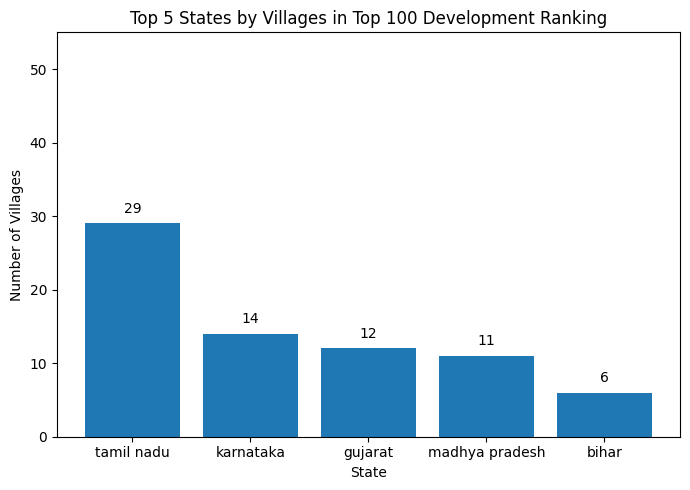

In [132]:
import matplotlib.pyplot as plt

top_100.drop_duplicates(subset = ['state_name', 'district', 'village'])

plt.figure(figsize=(7,5))

bars = plt.bar(
    state_wise[:5].index,
    state_wise[:5].values
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )

plt.xlabel("State")
plt.ylabel("Number of Villages")
plt.title("Top 5 States by Villages in Top 100 Development Ranking")

plt.ylim(0, 55)
plt.tight_layout()
plt.show()

In [91]:
corr = total_df[
    ["NDVI_index", "NL_index", "composite_dev_index"]
].corr()

print(corr)

                     NDVI_index  NL_index  composite_dev_index
NDVI_index             1.000000 -0.377062             0.062813
NL_index              -0.377062  1.000000             0.116007
composite_dev_index    0.062813  0.116007             1.000000


#### Top 5 states with highest number of women representatives

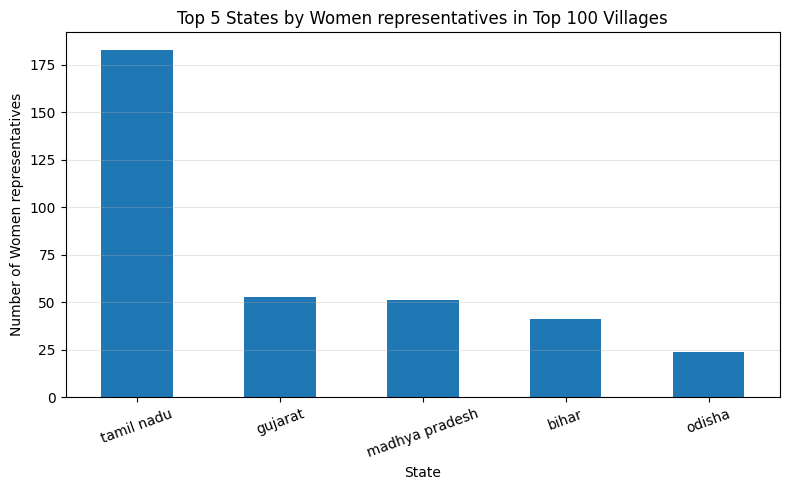

state_name
tamil nadu          183.0
gujarat              53.0
madhya pradesh       51.0
bihar                41.0
odisha               24.0
uttar pradesh        14.0
karnataka            13.0
chhattisgarh         12.0
assam                 6.0
punjab                5.0
maharashtra           5.0
andhra pradesh        4.0
rajasthan             2.0
west bengal           2.0
uttarakhand           2.0
telangana             1.0
himachal pradesh      0.0
Name: no_of_elected_women_representives, dtype: float64

In [118]:
women_rep = top_100.groupby("state_name")["no_of_elected_women_representives"]\
    .sum()\
    .sort_values(ascending=False)

plt.figure(figsize=(8,5))

women_rep.head(5).plot(kind="bar")

plt.xlabel("State")
plt.ylabel("Number of Women representatives")
plt.title("Top 5 States by Women representatives in Top 100 Villages")

plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()
women_rep

#### Top 5 states with highest number of villages that has computer labs in Schools

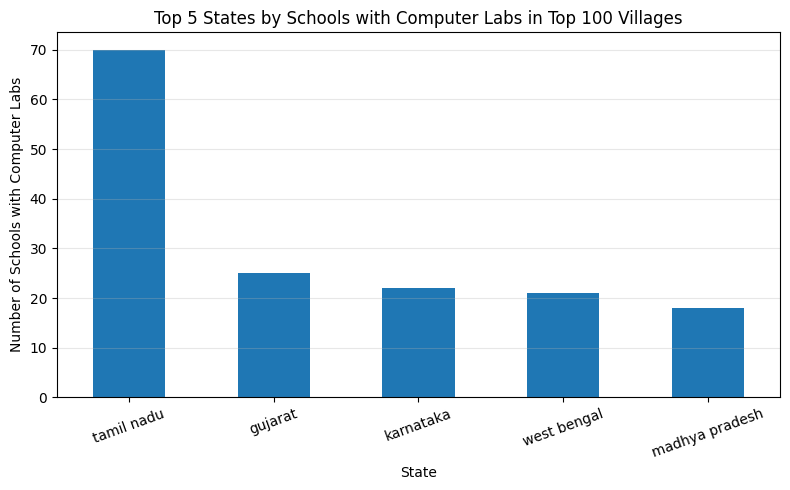

state_name
tamil nadu          70.0
gujarat             25.0
karnataka           22.0
west bengal         21.0
madhya pradesh      18.0
bihar               15.0
odisha               6.0
maharashtra          5.0
andhra pradesh       2.0
uttarakhand          1.0
himachal pradesh     1.0
chhattisgarh         1.0
rajasthan            1.0
telangana            1.0
assam                0.0
punjab               0.0
uttar pradesh        0.0
Name: total_no_of_schools_primary_with_computer_lab, dtype: float64

In [116]:
school_comp = top_100.groupby("state_name")["total_no_of_schools_primary_with_computer_lab"]\
    .sum()\
    .sort_values(ascending=False)

plt.figure(figsize=(8,5))

school_comp.head(5).plot(kind="bar")

plt.xlabel("State")
plt.ylabel("Number of Schools with Computer Labs")
plt.title("Top 5 States by Schools with Computer Labs in Top 100 Villages")

plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()
school_comp

#### Top 5 states with nearest hospitals in their villages

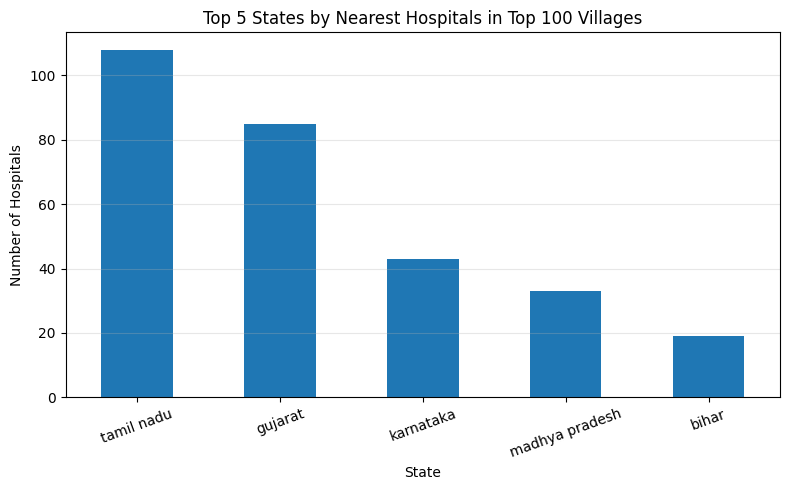

In [120]:
hospital = top_100.groupby("state_name")["distance_of_nearest_empaneled_hospital"]\
    .sum()\
    .sort_values(ascending=False)

plt.figure(figsize=(8,5))

hospital.head(5).plot(kind="bar")

plt.xlabel("State")
plt.ylabel("Number of Hospitals")
plt.title("Top 5 States by Nearest Hospitals in Top 100 Villages")

plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Spatial visualization

In [ ]:
# Read India state boundary shapefile
states = gpd.read_file("D:\SANJAY\Survey of India\STATE_BOUNDARY.shp")
states.head(3)

<>:1: SyntaxWarning: invalid escape sequence '\S'
<>:1: SyntaxWarning: invalid escape sequence '\S'
C:\Users\user\AppData\Local\Temp\ipykernel_7568\2582795078.py:1: SyntaxWarning: invalid escape sequence '\S'
  states = gpd.read_file("D:\SANJAY\Survey of India\STATE_BOUNDARY.shp")


,OBJECTID_1,OBJECTID,STATE,Shape_Leng,Shape_Area,geometry
0,1,1,DADRA & NAGAR HAVELI & DAMAN & DIU,321582.368237,5.797731e+08,"MULTIPOLYGON (((3278305.843 3619549.074, 32784..."
1,2,2,DISPUTED (MADHYA PRADESH & GUJARAT),18063.055390,4.222065e+06,"MULTIPOLYGON (((3413880.67 3832259.287, 341391..."
2,3,3,DISPUTED (MADHYA PRADESH & RAJASTHAN),43844.449759,1.525304e+07,"MULTIPOLYGON (((3471523.664 3925194.933, 34715..."


In [ ]:
# Ensure same crs
states.to_crs(top_100.crs, inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_7568\524476616.py:21: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()
C:\Users\user\AppData\Local\Temp\ipykernel_7568\524476616.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


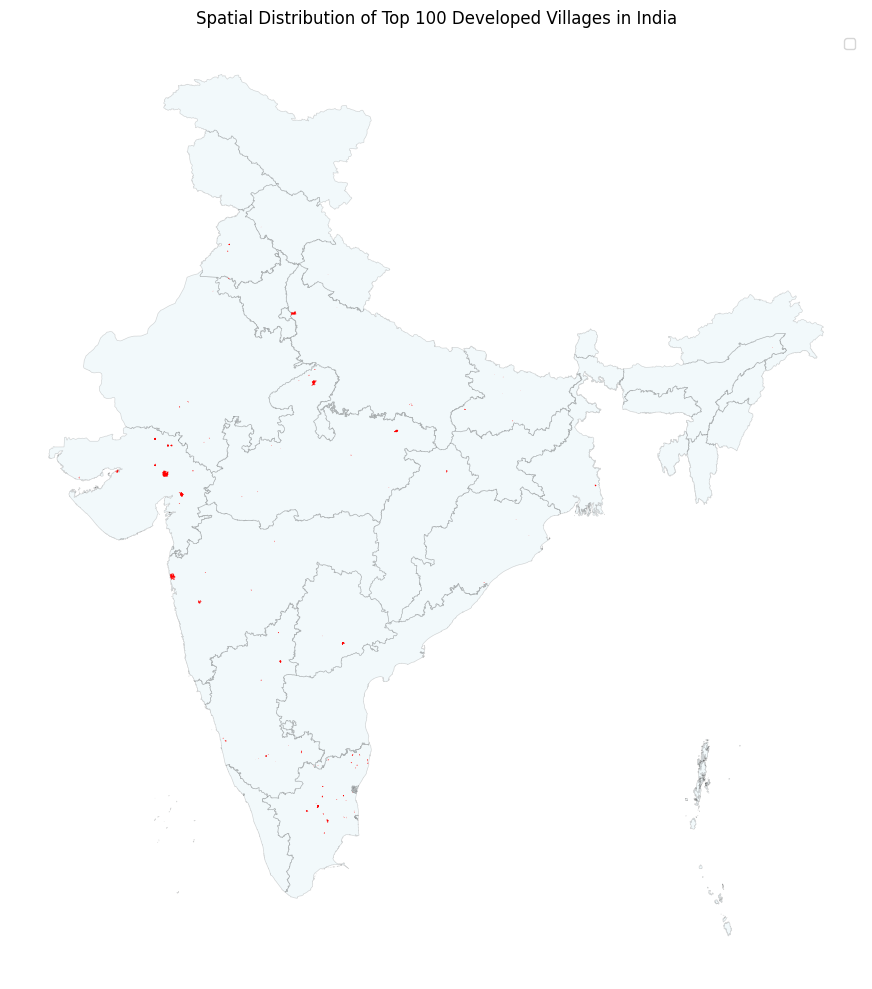

In [ ]:
# Visualize top 100 developed villages overlayed on State boundaries

fig, ax = plt.subplots(figsize=(10, 10))

states.plot(
    ax=ax,
    alpha=0.15,
    facecolor="lightblue",
    edgecolor="black",
    linewidth=0.5
)

# Top 100 villages
top_100.plot(
    ax=ax,
    color="red",
    markersize=8,
    label="Top 100 villages"
)

plt.title("Spatial Distribution of Top 100 Developed Villages in India")

plt.legend()
ax.set_axis_off()

plt.tight_layout()
plt.show()

In [149]:
states['STATE'] = states['STATE'].str.capitalize()

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))

states.plot(
    ax=ax,
    alpha=0.15,
    facecolor="lightblue",
    edgecolor="black",
    linewidth=0.5
)

# Top 100 villages
states[states].plot(
    ax=ax,
    color="red",
    markersize=8,
    label="Top 100 villages"
)

plt.title("Spatial Distribution of Top 100 Developed Villages in India")

plt.legend()
ax.set_axis_off()

plt.tight_layout()
plt.show()

In [128]:
top_100.drop_duplicates(subset = ['state_name', 'district', 'village']).to_csv('output/top100_villages.csv')

In [123]:
villages['state_name']

0         andhra pradesh
1         andhra pradesh
2         andhra pradesh
3         andhra pradesh
4         andhra pradesh
               ...      
653611       west bengal
653612       west bengal
653613       west bengal
653614       west bengal
653615       west bengal
Name: state_name, Length: 653616, dtype: object

In [108]:
for col in ["state_name", "district", "village"]:
    total_df[col] = total_df[col].astype(str).str.strip().str.lower()
    villages[col] = villages[col].astype(str).str.strip().str.lower()

In [109]:
villages_ranked = villages.merge(
    total_df,
    on=["state_name", "district", "village"],
    how="inner"
)

In [112]:
villages_ranked

,id_x,objectid_1_x,objectid_x,village,vlcode_x,gram_panch_x,gram_pan_1_x,block_x,bkcode_x,subdistric_x,...,infra_index,water_index,health_edu_index,econ_index,digital_index,gov_index,development_index,composite_dev_index,composite_dev_index_100,rank
0,302,302,302.000000000000000,reserved forest,999999,None,None,None,None,Kuppam,...,0.375,0.714286,0.333333,0.285714,0.4,0.625,0.498018,0.367016,36.701631,23983.0
1,302,302,302.000000000000000,reserved forest,999999,None,None,None,None,Kuppam,...,0.250,0.571429,0.111111,0.285714,0.4,0.750,0.396150,0.316082,31.608243,58419.0
2,302,302,302.000000000000000,reserved forest,999999,None,None,None,None,Kuppam,...,0.250,0.571429,0.333333,0.285714,0.4,0.625,0.431611,0.333813,33.381293,43589.0
3,302,302,302.000000000000000,reserved forest,999999,None,None,None,None,Kuppam,...,0.375,0.714286,0.333333,0.142857,0.2,0.625,0.452029,0.344022,34.402173,36555.0
4,302,302,302.000000000000000,reserved forest,999999,None,None,None,None,Kuppam,...,0.000,0.000000,0.000000,0.000000,0.0,0.000,0.000000,0.118007,11.800746,516250.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1125846,6261,6261,585257.000000000000000,asanbani,335704,None,None,Binpur - II,288,None,...,0.000,0.000000,0.111111,0.142857,0.0,0.000,0.048456,0.140307,14.030663,474204.0
1125847,6261,6261,585257.000000000000000,asanbani,335704,None,None,Binpur - II,288,None,...,0.125,0.000000,0.000000,0.000000,0.2,0.000,0.056892,0.144525,14.452451,463403.0
1125848,6261,6261,585257.000000000000000,asanbani,335704,None,None,Binpur - II,288,None,...,0.125,0.000000,0.111111,0.000000,0.4,0.000,0.103762,0.167960,16.795960,389428.0
1125849,6261,6261,585257.000000000000000,asanbani,335704,None,None,Binpur - II,288,None,...,0.125,0.000000,0.111111,0.000000,0.2,0.000,0.081560,0.156859,15.685877,426769.0


In [186]:
villages_ranked.to_parquet('villages_ranked.parquet')

In [111]:
villages['geometry']

0         MULTIPOLYGON (((79.18781 13.111, 79.18821 13.1...
1         MULTIPOLYGON (((78.31274 12.71076, 78.31457 12...
2         MULTIPOLYGON (((79.52754 13.66969, 79.52804 13...
3         MULTIPOLYGON (((79.54176 13.6125, 79.54109 13....
4         MULTIPOLYGON (((78.44424 12.78108, 78.44418 12...
                                ...                        
653611    MULTIPOLYGON (((86.81703 22.5975, 86.8163 22.5...
653612    MULTIPOLYGON (((86.8134 22.59641, 86.81326 22....
653613    MULTIPOLYGON (((86.78432 22.59598, 86.78386 22...
653614    MULTIPOLYGON (((86.7795 22.58913, 86.77914 22....
653615    MULTIPOLYGON (((86.83093 22.5709, 86.83096 22....
Name: geometry, Length: 653616, dtype: geometry

In [188]:
villages_ranked.to_file('villages_ranked.geojson')

In [ ]:
villages_ranked.to_file('villages_ranked.shp')

In [105]:
###############################

In [106]:
type(total_df)

pandas.core.frame.DataFrame